In [52]:
import pandas as pd
import numpy as np
import seaborn as sns

In [53]:

# import wine dataset

# sns.get_dataset_names()
df = sns.load_dataset('mpg')

In [54]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [55]:
y = df['mpg']

In [56]:
df.drop(columns=['mpg', 'origin', 'name'], inplace=True)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cylinders     398 non-null    int64  
 1   displacement  398 non-null    float64
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 18.8 KB


In [58]:
df.dropna(inplace=True)

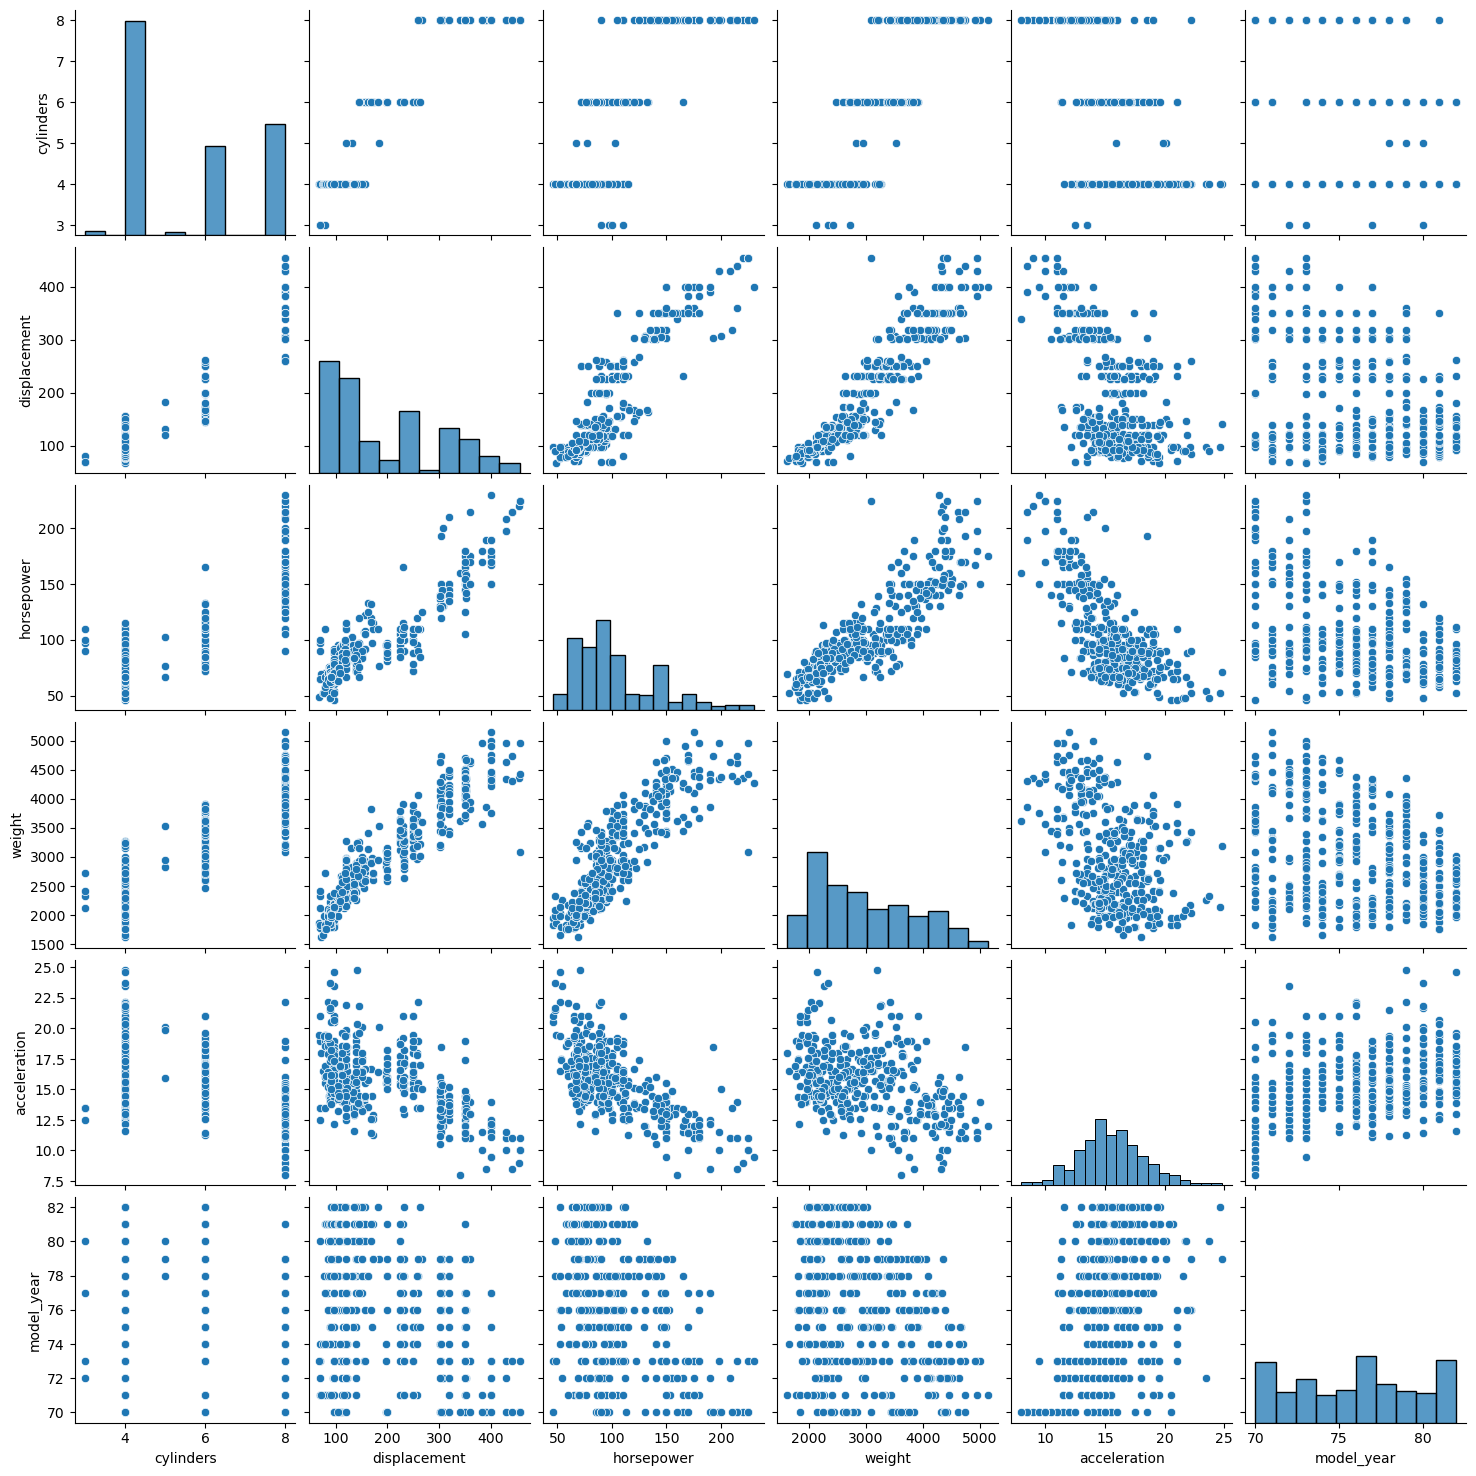

In [59]:
sns.pairplot(df)

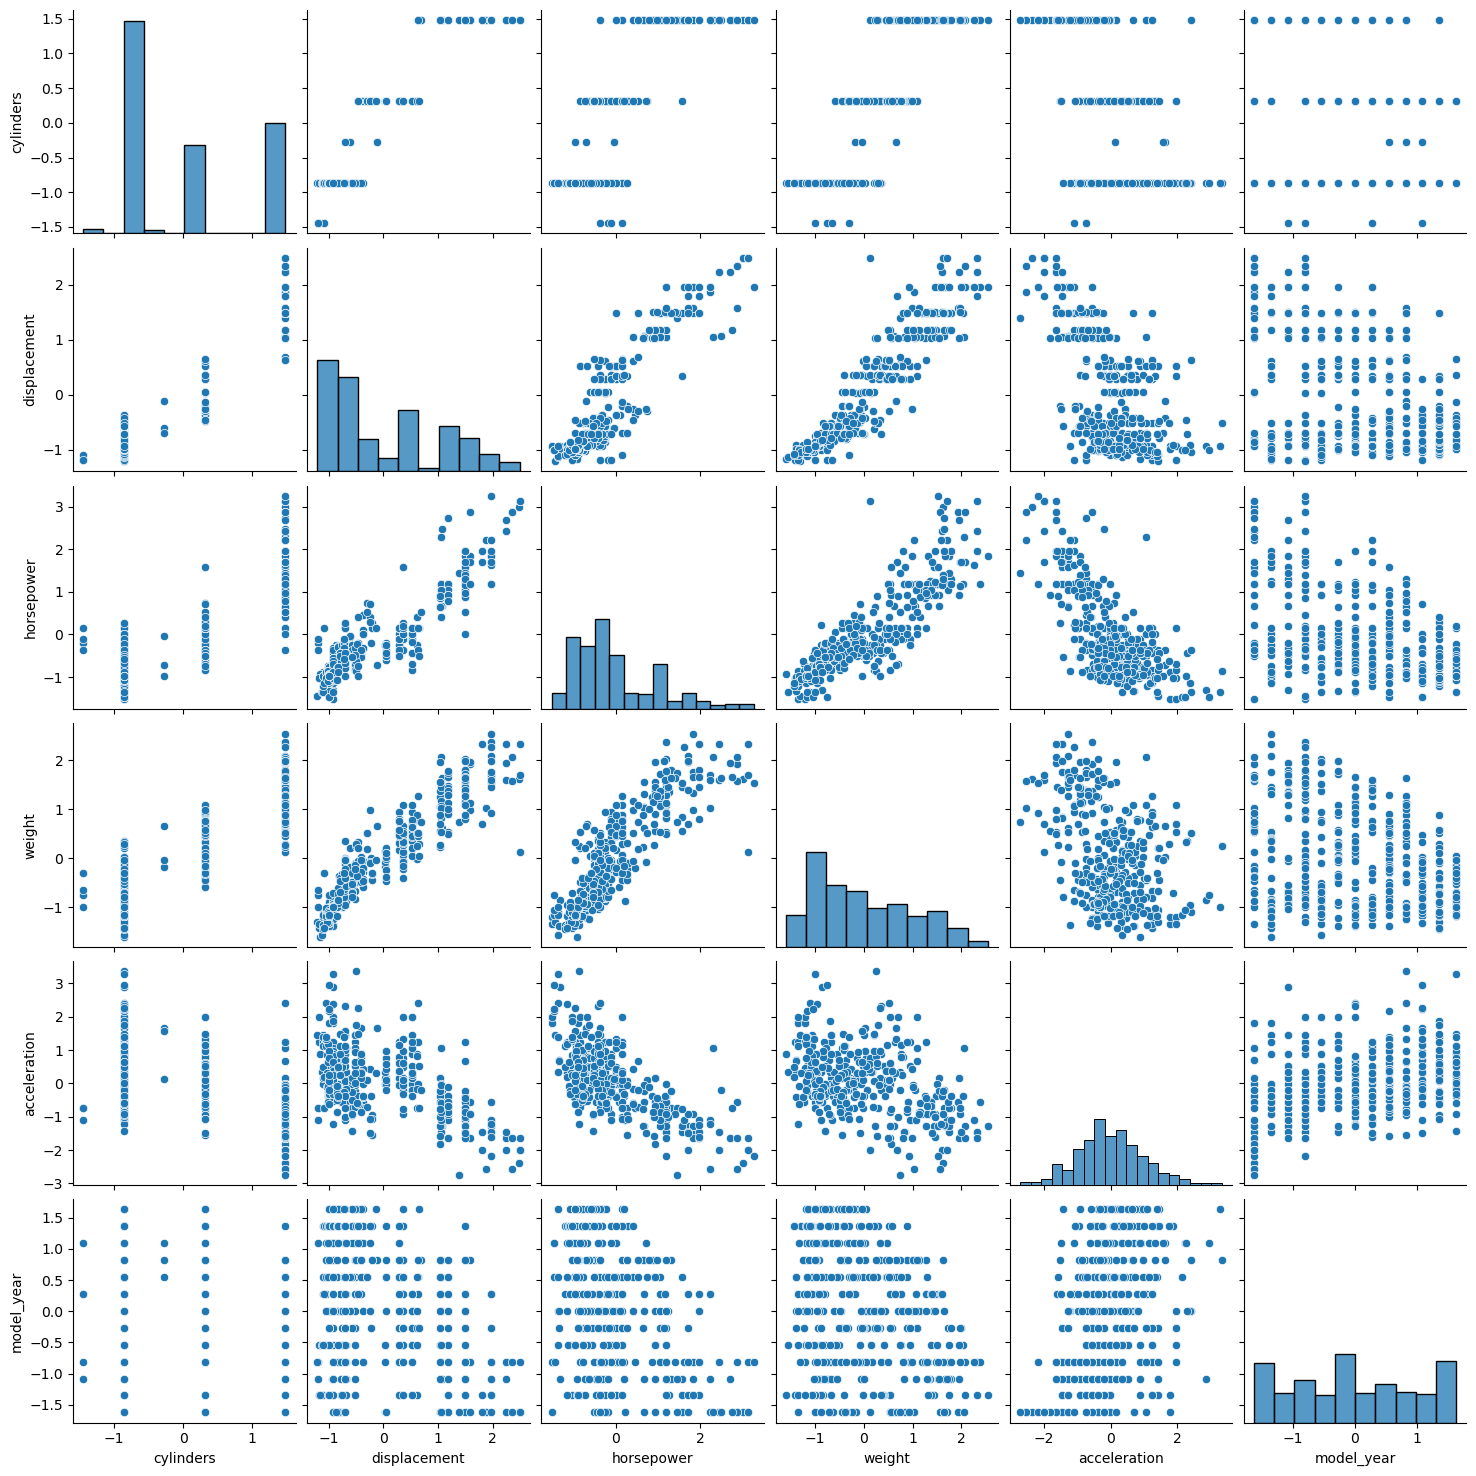

In [60]:
df = df.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
sns.pairplot(df)


In [61]:
cov = np.dot(df.T, df) / (len(df) - 1)

In [62]:
eigval, eigvec = np.linalg.eig(cov)
eigval, eigvec


(array([4.25715181, 0.83960969, 0.67281909, 0.13286878, 0.03637778,
        0.06117285]),
 array([[-0.45476297, -0.18949971,  0.16787927,  0.66043399, -0.46686768,
          0.27378563],
        [-0.46885724, -0.16303989,  0.13153149,  0.18824633,  0.83716918,
          0.00119299],
        [-0.46365868, -0.01052532, -0.12497783, -0.61826946, -0.10393605,
          0.61337637],
        [-0.44625213, -0.25716695,  0.27008821, -0.35122423, -0.26248935,
         -0.68521342],
        [ 0.32464331, -0.22125982,  0.86433834, -0.14811227,  0.03583935,
          0.27449654],
        [ 0.23205586, -0.90681107, -0.34477262, -0.02893841,  0.01394673,
          0.06279853]]))

In [63]:
# now to find the 95% variance, we need to find the cumulative sum of the eigenvalues and find the point where it reaches 95% of the total variance


sum = np.sum(eigval)
eigValPersentage = [(i / sum) * 100 for i in eigval]

eigval, eigValPersentage


(array([4.25715181, 0.83960969, 0.67281909, 0.13286878, 0.03637778,
        0.06117285]),
 [70.95253010641599,
  13.993494910485863,
  11.213651439348883,
  2.2144797380643317,
  0.6062962901146912,
  1.019547515570229])

In [ ]:
# the first 3 eigenvalues account for 95% of the variance, so we can project the data onto the first 3 eigenvectors to reduce the dimensionality to 3
df = pd.DataFrame(np.dot(df, eigvec[:3].T))

In [65]:
a = [70.95253010641599,
  13.993494910485863,
  11.213651439348883,
  2.2144797380643317,
  0.6062962901146912,
  1.019547515570229]

In [66]:
s = 0
for i in a:
    print(s+i)
    s += i

70.95253010641599
84.94602501690186
96.15967645625074
98.37415619431506
98.98045248442975
99.99999999999997


In [67]:
a[:3]

[70.95253010641599, 13.993494910485863, 11.213651439348883]